In [1]:
from pathlib import Path
import pandas as pd 
import glob
import numpy as np
from tqdm.autonotebook import tqdm as notebook_tqdm
notebook_tqdm.pandas()
import xgboost as xgb
from scipy.optimize import minimize_scalar
from sklearn.metrics import f1_score

root = Path('/data/data/malpolon/xgb') 
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

xgb.set_config(verbosity=0)

/tmp/ipykernel_46397/3901975081.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm as notebook_tqdm


In [8]:
## Load targets and Deep-SDM predictions
fulldf = pd.read_csv(root / 'database_split.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

xgb_f1 = pd.read_csv(root / f'xgbmm-test-f1.csv', index_col = 0)
#mm_f1 = pd.read_csv(root / f'all-test-f1-mm.csv', index_col = 0)
#loop_f1 = pd.read_csv(root / f'allloop-test-f1.csv', index_col = 0)
#loop2_f1 = pd.read_csv(root / f'allloop2-test-f1.csv', index_col = 0)
#mlp_f1 = pd.read_csv(root / f'allmlp-test-f1.csv', index_col = 0)
#mlp2_f1 = pd.read_csv(root / f'allmlp2-test-f1.csv', index_col = 0)

cp = '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31'
mm_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

# cp = '31_hum_env_dhw_bathy_common_pa-2025-11-12_15-13'
# deepxgb_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

cp = '15_humenv_cat_pa-2025-10-27_11-39'
envhum_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

cp = '37_mm4_transductif-2025-12-02_12-47'
td_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

## Prepare data

In [ ]:
def get_compound_values(row):

    survey_id = row.name
    
    inputs_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')

    filename = Path(inputs_path) / "env" / (str(survey_id) + '.npy')
    x = np.load(filename).astype(np.float32)
    env = np.transpose(x, (2, 0, 1))

    filename = Path(inputs_path) / "hum" / (str(survey_id) + '.npy')
    x = np.load(filename).astype(np.float32)
    hum = np.transpose(x, (2, 0, 1))

    envhum = np.concatenate([env, hum], axis=0)

    center_values = 0.25 * (envhum[:, 16, 16] + envhum[:, 15, 16] + envhum[:, 16, 15] + envhum[:, 15, 15])
    means = np.mean(envhum, axis=(1,2))
    deviations = np.std(envhum, axis=(1,2)) / means


    filename = Path(inputs_path) / "dhw" / (str(survey_id) + '.npy')
    dhw = np.load(filename).astype(np.float32)
    dhw_vect = np.array([np.mean(dhw), np.std(dhw) / np.mean(dhw), np.max(dhw)])

    return np.concatenate([center_values, means, deviations, dhw_vect])


  3%|▎         | 741/27437 [03:19<1:54:45,  3.88it/s]/tmp/ipykernel_79695/1252176004.py:24: RuntimeWarning: invalid value encountered in scalar divide
  dhw_vect = np.array([np.mean(dhw), np.std(dhw) / np.mean(dhw), np.max(dhw)])
  3%|▎         | 758/27437 [03:24<2:10:29,  3.41it/s]/tmp/ipykernel_79695/1252176004.py:19: RuntimeWarning: invalid value encountered in divide
  deviations = np.std(envhum, axis=(1,2)) / means
100%|██████████| 27437/27437 [2:06:57<00:00,  3.60it/s]  


In [ ]:
X = fulldf[['subset']].progress_apply(get_compound_values, axis=1, result_type='expand')
X.to_csv(root / f'X_compound_values_mm.csv')

## Train

In [13]:
# Prepare datasets

def get_datasets(sp):

    #X
    X = pd.read_csv(root / f'X_compound_values_mm.csv', index_col = 0)
    X_train = X.loc[fulldf['subset'] == 'train']
    X_val = X.loc[fulldf['subset'] == 'val']
    X_test = X.loc[fulldf['subset'] == 'test']

    # Y
    targets = (fulldf[sp] > 0).astype(float)
    Y_train = targets.loc[fulldf['subset'] == 'train'].astype('category')
    Y_val = targets.loc[fulldf['subset'] == 'val'].astype('category')
    Y_test = targets.loc[fulldf['subset'] == 'test'].astype('category')

    dtrain_clf = xgb.DMatrix(X_train, Y_train, enable_categorical=True)
    dval_clf = xgb.DMatrix(X_val, Y_val, enable_categorical=True)
    dtest_clf = xgb.DMatrix(X_test, Y_test, enable_categorical=True)

    return dtrain_clf, dval_clf, dtest_clf


In [14]:
for sp in notebook_tqdm(deepsdm_f1.index.to_list()):

   # Train

   dtrain_clf, dval_clf, dtest_clf = get_datasets(sp)
   evals = [(dtrain_clf, "train"), (dval_clf, "validation")]

   params = {"objective": "binary:logistic", "tree_method": "hist", "device": "cuda","subsample":0.3,"max_depth":5,"eval_metric":"auc","base_score":0.5}
   n=500

   model = xgb.train(
      params=params,
      dtrain=dtrain_clf,
      num_boost_round=n,
      evals=evals,
      verbose_eval=10
   )

   # Export predictions

   targets = (fulldf[sp] > 0).astype(float)
   Y_train = targets.loc[fulldf['subset'] == 'train'].astype('category')
   Y_val = targets.loc[fulldf['subset'] == 'val'].astype('category')
   Y_test = targets.loc[fulldf['subset'] == 'test'].astype('category')

   print(sp)
   pd.Series(model.predict(dtrain_clf), name=sp, index = Y_train.index).to_csv(root / 'xgb-preds' / f"train_{sp.replace('/','-')}.csv")
   pd.Series(model.predict(dval_clf), name=sp, index = Y_val.index).to_csv(root / 'xgb-preds' / f"val_{sp.replace('/','-')}.csv")
   pd.Series(model.predict(dtest_clf), name=sp, index = Y_test.index).to_csv(root / 'xgb-preds' / f"test_{sp.replace('/','-')}.csv")

  0%|          | 0/1796 [00:00<?, ?it/s]

[0]	train-auc:0.77475	validation-auc:0.50373
[10]	train-auc:0.99647	validation-auc:0.84410
[20]	train-auc:0.99820	validation-auc:0.90030
[30]	train-auc:0.99868	validation-auc:0.94570
[40]	train-auc:0.99906	validation-auc:0.95949
[50]	train-auc:0.99919	validation-auc:0.95387
[60]	train-auc:0.99939	validation-auc:0.94751
[70]	train-auc:0.99938	validation-auc:0.93438
[80]	train-auc:0.99951	validation-auc:0.94702
[90]	train-auc:0.99947	validation-auc:0.95479
[100]	train-auc:0.99949	validation-auc:0.96574
[110]	train-auc:0.99949	validation-auc:0.96670
[120]	train-auc:0.99952	validation-auc:0.96506
[130]	train-auc:0.99953	validation-auc:0.95573
[140]	train-auc:0.99950	validation-auc:0.95713
[150]	train-auc:0.99955	validation-auc:0.94702
[160]	train-auc:0.99956	validation-auc:0.94876
[170]	train-auc:0.99954	validation-auc:0.95113
[180]	train-auc:0.99955	validation-auc:0.95229
[190]	train-auc:0.99957	validation-auc:0.94633
[200]	train-auc:0.99957	validation-auc:0.94596
[210]	train-auc:0.99957	

  0%|          | 1/1796 [00:04<2:22:46,  4.77s/it]

[0]	train-auc:0.69082	validation-auc:0.50435
[10]	train-auc:0.99616	validation-auc:0.79189
[20]	train-auc:0.99825	validation-auc:0.90146
[30]	train-auc:0.99865	validation-auc:0.88216
[40]	train-auc:0.99885	validation-auc:0.88811
[50]	train-auc:0.99895	validation-auc:0.88753
[60]	train-auc:0.99910	validation-auc:0.90320
[70]	train-auc:0.99917	validation-auc:0.88983
[80]	train-auc:0.99928	validation-auc:0.88912
[90]	train-auc:0.99928	validation-auc:0.88450
[100]	train-auc:0.99933	validation-auc:0.87099
[110]	train-auc:0.99937	validation-auc:0.86560
[120]	train-auc:0.99941	validation-auc:0.88232
[130]	train-auc:0.99944	validation-auc:0.87299
[140]	train-auc:0.99947	validation-auc:0.87827
[150]	train-auc:0.99944	validation-auc:0.87109
[160]	train-auc:0.99948	validation-auc:0.87538
[170]	train-auc:0.99952	validation-auc:0.86945
[180]	train-auc:0.99952	validation-auc:0.86005
[190]	train-auc:0.99951	validation-auc:0.85500
[200]	train-auc:0.99953	validation-auc:0.85083
[210]	train-auc:0.99954	

  0%|          | 2/1796 [00:07<1:38:16,  3.29s/it]

...

100%|█████████▉| 1794/1796 [58:40<00:03,  1.83s/it]

[0]	train-auc:nan	validation-auc:nan
[10]	train-auc:nan	validation-auc:nan
[20]	train-auc:nan	validation-auc:nan
[30]	train-auc:nan	validation-auc:nan
[40]	train-auc:nan	validation-auc:nan
[50]	train-auc:nan	validation-auc:nan
[60]	train-auc:nan	validation-auc:nan
[70]	train-auc:nan	validation-auc:nan
[80]	train-auc:nan	validation-auc:nan
[90]	train-auc:nan	validation-auc:nan
[100]	train-auc:nan	validation-auc:nan
[110]	train-auc:nan	validation-auc:nan
[120]	train-auc:nan	validation-auc:nan
[130]	train-auc:nan	validation-auc:nan
[140]	train-auc:nan	validation-auc:nan
[150]	train-auc:nan	validation-auc:nan
[160]	train-auc:nan	validation-auc:nan
[170]	train-auc:nan	validation-auc:nan
[180]	train-auc:nan	validation-auc:nan
[190]	train-auc:nan	validation-auc:nan
[200]	train-auc:nan	validation-auc:nan
[210]	train-auc:nan	validation-auc:nan
[220]	train-auc:nan	validation-auc:nan
[230]	train-auc:nan	validation-auc:nan
[240]	train-auc:nan	validation-auc:nan
[250]	train-auc:nan	validation-auc:n

100%|█████████▉| 1795/1796 [58:42<00:01,  1.82s/it]

[0]	train-auc:0.50000	validation-auc:0.50000
[10]	train-auc:0.95762	validation-auc:0.70387
[20]	train-auc:0.99181	validation-auc:0.86169
[30]	train-auc:0.99467	validation-auc:0.94249
[40]	train-auc:0.99607	validation-auc:0.95029
[50]	train-auc:0.99771	validation-auc:0.94290
[60]	train-auc:0.99824	validation-auc:0.94364
[70]	train-auc:0.99896	validation-auc:0.94634
[80]	train-auc:0.99866	validation-auc:0.93646
[90]	train-auc:0.99842	validation-auc:0.95121
[100]	train-auc:0.99893	validation-auc:0.96263
[110]	train-auc:0.99898	validation-auc:0.96116
[120]	train-auc:0.99897	validation-auc:0.94839
[130]	train-auc:0.99932	validation-auc:0.93375
[140]	train-auc:0.99936	validation-auc:0.92865
[150]	train-auc:0.99945	validation-auc:0.93548
[160]	train-auc:0.99936	validation-auc:0.94393
[170]	train-auc:0.99966	validation-auc:0.93565
[180]	train-auc:0.99967	validation-auc:0.92820
[190]	train-auc:0.99981	validation-auc:0.93846
[200]	train-auc:0.99982	validation-auc:0.94139
[210]	train-auc:0.99986	

100%|██████████| 1796/1796 [58:44<00:00,  1.96s/it]


## Calculate threshold

In [15]:
dfdict = {}

for sp in notebook_tqdm(deepsdm_f1.index.to_list()):

    dfdict[sp] = pd.read_csv(root / 'xgb-preds' / f"val_{sp.replace('/','-')}.csv", index_col=0).squeeze()

xgb_val = pd.DataFrame(dfdict)


100%|██████████| 1796/1796 [00:08<00:00, 202.88it/s]


In [16]:
# Find best threshold for species richness

def rvalue(thres, df, target_sr):
    sr = (df > thres).astype(int).sum(axis=1)
    
    return np.abs(sr.mean() - target_sr.mean())



targets_sr = (fulldf.loc[xgb_val.index, xgb_val.columns] > 0).sum(axis=1)
threshold = minimize_scalar(rvalue, args=(xgb_val, targets_sr),method='Bounded', bounds=(0,1))['x']
print(threshold)

0.05753493795686595


## Calculate F1

In [18]:
THRESHOLD = 0.0575

dfdict = {}

for sp in notebook_tqdm(deepsdm_f1.index.to_list()):

    dfdict[sp] = pd.read_csv(root / 'xgb-preds' / f"val_{sp.replace('/','-')}.csv", index_col=0).squeeze()

xgb_test = (pd.DataFrame(dfdict) > THRESHOLD)

100%|██████████| 1796/1796 [00:07<00:00, 229.46it/s]


In [ ]:
## Save to files as inputs
xgbtest = pd.DataFrame(dfdict)
outfolder = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/xgbmm')

for s in notebook_tqdm(xgbtest.index.to_list()):
    np.save(outfolder / str(s), xgbtest.loc[s].values)

In [20]:
# Calculate average precision
scorename = 'f1' # / AP

dic = {}
for s in xgb_test.columns:
    preds = (xgb_test[s] > THRESHOLD).astype(float).to_numpy().flatten()
    targ = (fulldf.loc[xgb_test.index, s] > 0).astype(float).to_numpy().flatten()
    f1 = f1_score(targ, preds)
    dic[s] = {'f1': f1}
scores = pd.DataFrame(dic).T      

/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/venvs/xgb/lib/pytho

In [21]:
xgb_f1 = scores.sort_values(by=scorename, ascending=False)
xgb_f1.to_csv(root / f'xgbmm-test-{scorename}.csv')

In [ ]:
# Val F1 > 0.3
bestspecies = xgb_f1.index.to_list()[:97]
bestspecies

['Notolabrus tetricus',
 'Notolabrus gymnogenis',
 'Parma microlepis',
 'Acanthochromis polyacanthus',
 'Morwong fuscus',
 'Amblyglyphidodon curacao',
 'Ophthalmolepis lineolatus',
 'Atypichthys strigatus',
 'Notolabrus fucicola',
 'Achoerodus viridis',
 'Pictilabrus laticlavius',
 'Halichoeres melanurus',
 'Labroides dimidiatus',
 'Pomacentrus lepidogenys',
 'Trachinops taeniatus',
 'Neopomacentrus azysron',
 'Aplodactylus lophodon',
 'Scorpis lineolata',
 'Pomacentrus moluccensis',
 'Chlorurus sordidus',
 'Trachinops caudimaculatus',
 'Chrysiptera rollandi',
 'Scolopsis bilineata',
 'Ctenochaetus striatus',
 'Parupeneus spilurus',
 'Acanthaluteres vittiger',
 'Chaetodon aureofasciatus',
 'Stegastes gascoynei',
 'Pomacentrus milleri',
 'Thalassoma lunare',
 'Parma victoriae',
 'Neoodax balteatus',
 'Pomacentrus bankanensis',
 'Chromis hypsilepis',
 'Gomphosus varius',
 'Halichoeres hortulanus',
 'Olisthops cyanomelas',
 'Pseudogoniistius nigripes',
 'Lutjanus carponotatus',
 'Choerodo

## Compare

In [66]:
scores = pd.concat([xgb_f1["f1"], envhum_f1["f1"], mm_f1["f1"], td_f1["f1"]], axis = 1)
names = ['XGBoost', 'Deep-SDM', 'Multimodal', 'Transductive']
scores.columns = names

In [4]:
scores.dropna(inplace=True)

#### 1v1 Bland-Altman

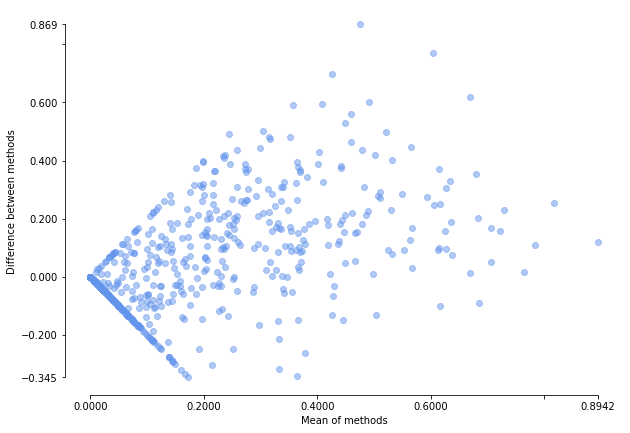

In [13]:
import pyCompare

pyCompare.blandAltman(scores[names[3]].values,scores[names[0]].values)

#### 1v1 Scatter plot

[Text(0.5, 0, 'XGBoost F1'), Text(0, 0.5, 'Transductif F1')]

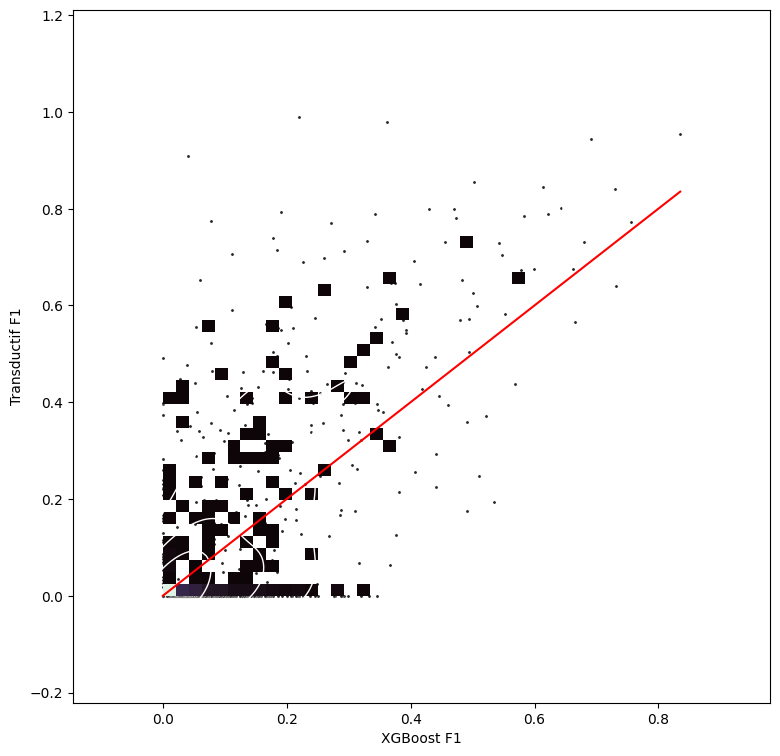

In [14]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[3]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[3] + ' F1')

#### XvX lineplot

In [67]:
y = []

for n in names:
    y1 = scores[[n]].sort_values(ascending=False, by=n)
    y1.reset_index(inplace=True)
    y1.columns = ['species', 'F1']
    y1['x'] = np.arange(len(y1))
    y1['model'] = n
    y.append(y1)

data = pd.concat(y)

In [68]:
import plotly.express as px

fig = px.line(data[data['x'] <= 400], x='x', y='F1', color='model', template = 'simple_white',
           width = 800, height=800,
           color_discrete_sequence = px.colors.qualitative.Pastel)

fig.update_layout(
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.update_traces(line={'width': 4})

#### 1v1 arrow scatter

In [62]:
scores['av'] = np.maximum(scores[names[0]], scores[names[3]])

<Axes: >

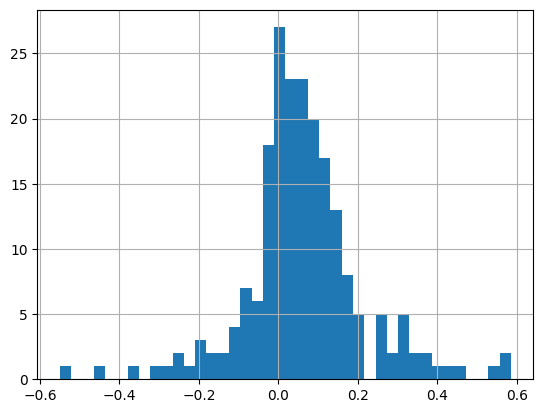

In [28]:
best_scores = scores[scores['av'] > 0.3]
(best_scores[names[3]] - best_scores[names[2]]).hist(bins=40)

In [63]:
best_scores = scores.sort_values(by='XGBoost', ascending=False)
best_scores = best_scores[best_scores['av'] > 0.4]
best_scores['x'] = np.arange(len(best_scores))

In [65]:
import plotly.graph_objects as go
import numpy as np

# Example data
x = best_scores['x']
y1 = best_scores['XGBoost']
y2 = best_scores['Transductif']
hover_text = best_scores.index.to_list()

# Create the figure
fig = go.Figure()

# Add the two series as scatter plots
fig.add_trace(go.Scatter(
    x=x, y=y1,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[0], size=10),
    name='XGBoost',
    hovertext=hover_text,
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=x, y=y2,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[3], size=10),
    name='Transductive',
    hovertext=hover_text,
    hoverinfo='text'
))

# Add arrows for the differences
for i in range(len(x)):
    fig.add_annotation(
        ax=x[i], ay=y1[i],
        axref='x', ayref='y',
        x=x[i], y=y2[i],
        xref='x', yref='y',
        showarrow=True,
        arrowhead=1,
        arrowsize=1.5,
        arrowcolor=px.colors.qualitative.Pastel1[1],
        arrowwidth=1.5,
    )


fig.update_layout(
    template='simple_white',
    width = 1200, height=800,
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)


/tmp/ipykernel_46397/3715843393.py:35: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_46397/3715843393.py:37: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

